# Capstone Project: Patient Classification and Readmission Prediction

**Question**: Can real-world evidence (RWE) from patient records be used to stratify patients with a specific disease into risk groups and predict their likelihood of readmission? 



### The Data

Our dataset comes from Kaggle [link](https://www.kaggle.com/datasets/sulphatet/diabetes-130us-hospitals-for-years-19992008). The dataset focuses on patients with diabetes as a primary diagnosis. It represents 10 years (1999-2008) of clinical care across 130 US hospitals and integrated delivery networks. It includes over 50 features representing patient and hospital outcomes. 

Two additional files are to be used in this exercies. The first is to assign the categorical labels for the numeralized features: admission type, discharge disposition, and admission sources. The second data file is a list of diagnoses pertaining to the ICD-9-CM codes used in the three diagnoses features (diag_1, diag_2, diag_3). ICD-9-CM are the standardized set of codes health care physicians (HCPs) utilize for patient charts, coding, and electronic medical records (EMRs). 


### Understanding the Data

To begin, we will run a series of code to analyze the status of our dataset. We will identify data types, missing data, and assess overall data structure that may present limitations its later application for modeling. 


In [1]:
# Importing relevant libraries
import pandas as pd
import matplotlib.pyplot as plt

# Loading dataset 
dbts= pd.read_csv("data/diabetic_data.csv")

# Missing values (percentage)
missing_counts=dbts.isnull().sum()
missing_percent=(dbts.isnull().sum() / len(dbts)) * 100
missing_summary=pd.DataFrame({
    'Missing Count': missing_counts,
    'Missing %': missing_percent
})


# Display dataset summary
print(dbts.dtypes)
print(dbts.describe())
print(missing_summary)


encounter_id                 int64
patient_nbr                  int64
race                        object
gender                      object
age                         object
weight                      object
admission_type_id            int64
discharge_disposition_id     int64
admission_source_id          int64
time_in_hospital             int64
payer_code                  object
medical_specialty           object
num_lab_procedures           int64
num_procedures               int64
num_medications              int64
number_outpatient            int64
number_emergency             int64
number_inpatient             int64
diag_1                      object
diag_2                      object
diag_3                      object
number_diagnoses             int64
max_glu_serum               object
A1Cresult                   object
metformin                   object
repaglinide                 object
nateglinide                 object
chlorpropamide              object
glimepiride         

Some oddities arise in our data regarding the typing. For example, 'weight','age' and 'A1C' are supposed to be numerical and theoretically bear great influence on our future model. Conversely, the diagnostic data we expect to be categorical are indeed integers. This stems from the use of ICD-9-CM coding that will have to be mapped against the diagnosis description to aid analysis. 

Unfortunately, 'A1C' and 'max_glu_serum' have over 80% of missing values. They will have to be excluded from our analysis. Another question arises when observing 'encounter_id' and 'patient_nbr'. It is possible that the same patient was hospitalized within our 10 year period. If so, we will have to identify these patients and decide on which encounter to utilize: first, last, or some combination. 

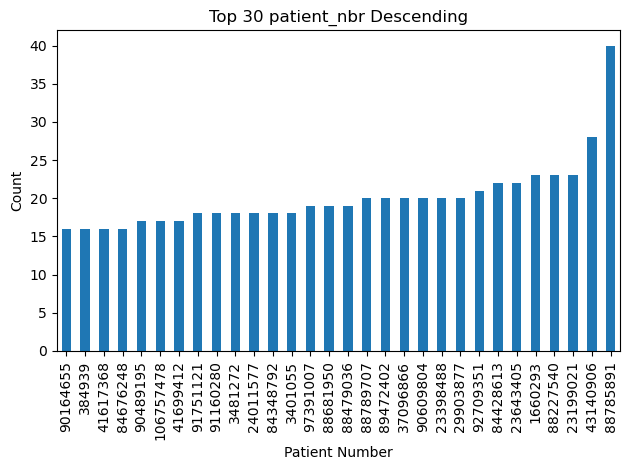

In [2]:
# Identifying patients with multiple encounters
counts = dbts['patient_nbr'].value_counts().head(30)

counts.sort_values().plot(kind='bar')

plt.title('Top 30 patient_nbr Descending')
plt.xlabel('Patient Number')
plt.ylabel('Count')
plt.tight_layout()

plt.show()

In [3]:
# Dozens of patients have multiple encounters
# While clinically significant, for the purposes of this exercise (the goal of which is to prove predictive power),
# this presents a data leakage risk. For the purposes of predicting readmission, I will only use the first encounter. 
# For the purpose of clustering, I will use an aggregate of the encounters. 

In [4]:
# Understanding Diagnoses
dbts[['diag_1','diag_2','diag_3']].head()

# these will need to be mapped against a reference sheet to make sense of the ICD-9-CM codes into actual diagnoses

,diag_1,diag_2,diag_3
0,250.83,?,?
1,276,250.01,255
2,648,250,V27
3,8,250.43,403
4,197,157,250


### Cleaning the Data

The following steps will be taken to prepare the data for analysis and modeling: missing observations will be removed, features with a majority of missing values will be excluded, 'object' features that require corresponding labels will be relabeled and binned into smaller broader categories to diminish the number of features (i.e. diagnoses will be categorized into "Broad Category" reducing the variables from 241 to 16).

For the purpopse of clustering and predicting classification into readmission, we will be utilizing only the first encounter presented per patient. The logic being that the model should be able to predict readmission based on the first visit. We can randomly select a sample from the remaining data (ensuring to only pull one encounter per patient) and use it to test our model. 

In [5]:
# We begin by removing features where a majority of their data is missing.
# A1Cresult, Max Glucose Serum, Weight, Payer (has no bearing on clinical outcome), Medical Specialty (cannot predict specialty for
# a new patient) 
dbts=dbts.drop(columns=['max_glu_serum','A1Cresult','weight','medical_specialty','payer_code'])

In [6]:
# Importing ICD-9-CM diagnoses reference sheet
icd9= pd.read_csv("data/icd9.csv")

# Mapping ICD-9-CM codes to diagnoses
# Issue presented where codes don't match up perfectly while data is 'object' type or 'int64' type. 'str' type will be necessary.
diag_columns=['diag_1','diag_2','diag_3']

# Converting codes to 'str'. Removing spaces and standardizing format. 
# Additionally, because we only need the "Broad Category" for diagnoses, we can drop the '.' and more 
# accurate diagnoses to simplify. This will require removing duplicates as indexing requires unique values.

for col in diag_columns:
    dbts[col]=dbts[col].astype(str).str.strip().str.split('.').str[0].str.upper()

icd9['ICD9_Code']=icd9['ICD9_Code'].astype(str).str.strip().str.split('.').str[0].str.upper()


icd9=(icd9.groupby('ICD9_Code')['Broad_Category'].first().reset_index())


# Creat mapping dictionary for diagnoses
icd9_map=dict(zip(icd9['ICD9_Code'], icd9['Broad_Category']))

# Map diagnoses

for col in diag_columns:
    dbts[col+'_cat']=dbts[col].map(icd9_map)


# Check for diagnoses mapping
dbts[['diag_1_cat','diag_2_cat','diag_3_cat']].head(100)
#print(dbts.dtypes)


,diag_1_cat,diag_2_cat,diag_3_cat
0,Diabetes Mellitus,NaN,NaN
1,Endocrine & Metabolic,Diabetes Mellitus,Endocrine & Metabolic
2,"Pregnancy, Perinatal & Congenital",Diabetes Mellitus,Supplementary Codes
3,Infectious & Parasitic,Diabetes Mellitus,Circulatory & Blood
4,Neoplasms,Neoplasms,Diabetes Mellitus
...,...,...,...
95,Injury & Poisoning,Circulatory & Blood,Circulatory & Blood
96,Infectious & Parasitic,Circulatory & Blood,Circulatory & Blood
97,Circulatory & Blood,Circulatory & Blood,Respiratory
98,Genitourinary,Diabetes Mellitus,Circulatory & Blood


In [7]:
# Removing diag codes as they are no longer pertinent to the anlaysis
dbts=dbts.drop(columns=['diag_1','diag_2','diag_3'])

In [8]:
# Importing Relevant admission type, admission source, and discharge disposition reference sheets
ad_source= pd.read_csv('data/admission_source.csv')
ad_type=pd.read_csv('data/admission_type.csv')
dis_dispo=pd.read_csv('data/discharge_dispo.csv')


In [9]:
# Creating mapping dictionaries
ad_source_map=dict(zip(ad_source['admission_source_id'],ad_source['description']))
ad_type_map=dict(zip(ad_type['admission_type_id'],ad_type['description']))
dis_dispo_map=dict(zip(dis_dispo['discharge_disposition_id'],dis_dispo['description']))


# Mapping admission type, source, and discharge disposition 
dbts['ad_source_desc'] = (dbts['admission_source_id'].map(ad_source_map))
dbts['ad_type_desc'] = (dbts['admission_type_id'].map(ad_type_map))
dbts['dis_dispo_desc'] = (dbts['discharge_disposition_id'].map(dis_dispo_map))

# Check
dbts[['ad_source_desc','ad_type_desc','dis_dispo_desc']].head(100)

#print(dbts['admission_type_id'].dtype)
#print(ad_type['admission_type_id'].dtype)

,ad_source_desc,ad_type_desc,dis_dispo_desc
0,Physician Referral,NaN,Not Mapped
1,Emergency Room,Emergency,Discharged to home
2,Emergency Room,Emergency,Discharged to home
3,Emergency Room,Emergency,Discharged to home
4,Emergency Room,Emergency,Discharged to home
...,...,...,...
95,Clinic Referral,Urgent,Discharged to home
96,Emergency Room,Emergency,Discharged/transferred to SNF
97,Emergency Room,Emergency,Discharged to home
98,Emergency Room,Emergency,Discharged to home


In [10]:
# Removing missing values
dbts = dbts.dropna(subset=['ad_source_desc','ad_type_desc','dis_dispo_desc'])

# Assessing occurence for each value
columns = ['ad_source_desc', 'ad_type_desc', 'dis_dispo_desc']

for col in columns:
    print(f"\nValue counts for {col}:\n")
    print(dbts[col].value_counts())



Value counts for ad_source_desc:

ad_source_desc
 Emergency Room                                               53890
 Physician Referral                                           28039
Transfer from a hospital                                       2669
 Transfer from another health care facility                    2226
Clinic Referral                                                 978
 Transfer from a Skilled Nursing Facility (SNF)                 740
 Not Mapped                                                     161
 Not Available                                                  125
HMO Referral                                                    102
 Court/Law Enforcement                                           15
 Transfer from hospital inpt/same fac reslt in a sep claim       12
 Transfer from critial access hospital                            8
 Extramural Birth                                                 2
Normal Delivery                                                   

In [11]:
# Need to remove the leading spaces in the ad_source_desc feature
dbts['ad_source_desc'] = dbts['ad_source_desc'].str.strip()

# Removing "Not Mapped" or "Not Available"
dbts = dbts[
    ~dbts['ad_source_desc'].str.lower().isin([
        'not mapped',
        'not available'
    ])
]

dbts = dbts[
    ~dbts['ad_type_desc'].str.lower().isin([
        'not mapped',
        'not available'
    ])
]

dbts = dbts[
    ~dbts['dis_dispo_desc'].str.lower().isin([
        'not mapped',
        'not available'
    ])
]

# Now we will rebin the features to ensure only the top ones
# ad_source_desc: Emergency Room, PHysician Referral, Group all "Transfer", and "Other"
def rebin_ad_source(x):
    
    x = str(x).strip()

    if x == 'Emergency Room':
        return 'Emergency Room'
    
    elif x == 'Physician Referral':
        return 'Physician Referral'
    
    elif 'Transfer' in x:
        return 'Transfer'
    
    else:
        return 'Other'


dbts['ad_source_new'] = dbts['ad_source_desc'].apply(rebin_ad_source)

# ad_type_desc: Emergency Room, PHysician Referral, Group all "Transfer", and "Other"
def rebin_ad_type(x):
    
    x = str(x).strip()

    if x == 'Emergency':
        return 'Emergency'
    
    elif x == 'Elective':
        return 'Elective'
    
    elif x == 'Urgent':
        return 'Urgent'
    
    else:
        return 'Other'


dbts['ad_type_new'] = dbts['ad_type_desc'].apply(rebin_ad_type)

# dis_dispo_desc: Emergency Room, PHysician Referral, Group all "Transfer", and "Other"
def rebin_dis_dispo(x):
    
    x = str(x).strip()

    if x == 'Discharged to home':
        return 'Home'
    
    elif x == 'Discharged/transferred to SNF':
        return 'SNF'
    
    elif x == 'Discharged/transferred to home with home health service':
        return 'Home Health'

    elif 'Expired' in x:
        return 'Expired'
    
    else:
        return 'Other'


dbts['dis_dispo_new'] = dbts['dis_dispo_desc'].apply(rebin_dis_dispo)

columns = ['ad_source_new', 'ad_type_new', 'dis_dispo_new']

for col in columns:
    print(f"\nValue counts for {col}:\n")
    print(dbts[col].value_counts())

dbts.info()


Value counts for ad_source_new:

ad_source_new
Emergency Room        53621
Physician Referral    26154
Transfer               5649
Other                  1086
Name: count, dtype: int64

Value counts for ad_type_new:

ad_type_new
Emergency    51183
Elective     17831
Urgent       17465
Other           31
Name: count, dtype: int64

Value counts for dis_dispo_new:

dis_dispo_new
Home           54572
SNF            11798
Home Health    11161
Other           7508
Expired         1471
Name: count, dtype: int64
<class 'pandas.core.frame.DataFrame'>
Index: 86510 entries, 1 to 101765
Data columns (total 51 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   encounter_id              86510 non-null  int64 
 1   patient_nbr               86510 non-null  int64 
 2   race                      86510 non-null  object
 3   gender                    86510 non-null  object
 4   age                       86510 non-null  object
 5   a

In [12]:
# Remove all the additional features created for ad_source/type, and discharge disposition
dbts=dbts.drop(columns=[
    'diag_1_cat',
    'diag_2_cat',
    'diag_3_cat',
    'ad_source_desc',
    'ad_type_desc',
    'dis_dispo_desc',   
])


In [13]:
dbts.info()

<class 'pandas.core.frame.DataFrame'>
Index: 86510 entries, 1 to 101765
Data columns (total 45 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   encounter_id              86510 non-null  int64 
 1   patient_nbr               86510 non-null  int64 
 2   race                      86510 non-null  object
 3   gender                    86510 non-null  object
 4   age                       86510 non-null  object
 5   admission_type_id         86510 non-null  int64 
 6   discharge_disposition_id  86510 non-null  int64 
 7   admission_source_id       86510 non-null  int64 
 8   time_in_hospital          86510 non-null  int64 
 9   num_lab_procedures        86510 non-null  int64 
 10  num_procedures            86510 non-null  int64 
 11  num_medications           86510 non-null  int64 
 12  number_outpatient         86510 non-null  int64 
 13  number_emergency          86510 non-null  int64 
 14  number_inpatient          

In [14]:
# Correct Age from range to decades. Current values read [50-60), changing to 50
dbts['age'] = dbts['age'].str.extract(r'(\d+)').astype(int)

Lower Bound: 20.0
Upper Bound: 100.0
Number of Outliers: 783
     age
1     10
66    10
232   10
425   10
933   10


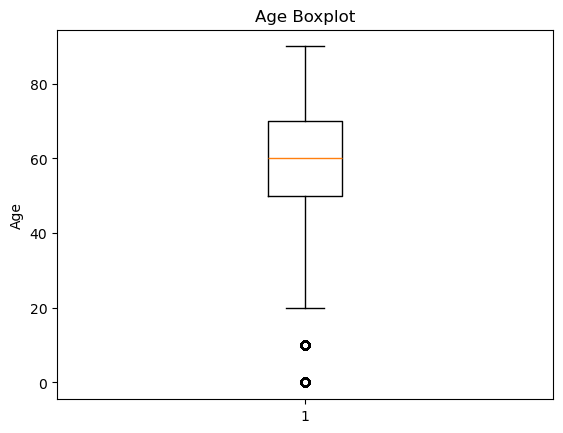

In [15]:
# Check age for outliers. Intuition drives me to remove anyone <20
Q1 = dbts['age'].quantile(0.25)
Q3 = dbts['age'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = dbts[
    (dbts['age'] < lower_bound) |
    (dbts['age'] > upper_bound)
]

print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)
print("Number of Outliers:", len(outliers))

print(outliers[['age']].head())

import matplotlib.pyplot as plt

plt.boxplot(dbts['age'])

plt.title('Age Boxplot')
plt.ylabel('Age')

plt.show()

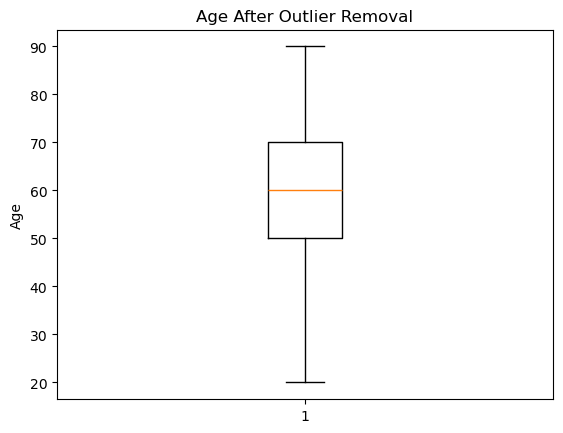

In [16]:
# Removing age outliers (<20)
Q1 = dbts['age'].quantile(0.25)
Q3 = dbts['age'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Keep only non-outliers
dbts = dbts[
    (dbts['age'] >= lower_bound) &
    (dbts['age'] <= upper_bound)
]

import matplotlib.pyplot as plt

plt.boxplot(dbts['age'])

plt.title('Age After Outlier Removal')
plt.ylabel('Age')

plt.show()

### Splitting the Data: First vs Subsequent Encounters
Now that diagnostic codes have been reclassified with their respective broad diagnosis description, age has been corrected and stripped of outliers, and admission type/source, and discharge disposition has been assigned the interpretable string values, we can split the data. 

We will be splitting the data into first encounter, and all others. The first encoutner subset will be our primary dataset for later modeling. 

In [17]:
# Get index of first encounter for each patient
first_idx = dbts.groupby('patient_nbr')['encounter_id'].idxmin()

# Subset 1: first encounter only
first_en= dbts.loc[first_idx]

# Subset 2: all subsequent encounters
subsequent_en= dbts.drop(first_idx)

# Check 
print(first_en['patient_nbr'].value_counts().head())

print(subsequent_en['patient_nbr'].value_counts().head())

patient_nbr
189502619    1
135          1
378          1
729          1
774          1
Name: count, dtype: int64
patient_nbr
88785891    39
88227540    22
23199021    22
43140906    21
84428613    21
Name: count, dtype: int64


### Clustering Model Development
Now that the data has been split into two subsets, we are ready to move forward with developing a clustering model to see if we can risk stratefy the patients. 

In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.decomposition import PCA

In [19]:
#Numerical features: hosptial utilization + comorbidity
cluster_num_features = [
    'time_in_hospital',
    'num_lab_procedures',
    'num_procedures',
    'num_medications',
    'number_outpatient',
    'number_emergency',
    'number_inpatient',
    'number_diagnoses',
    'age'
]

#Categorical features: admission type/source, and dishcarge dispositoin
cluster_cat_features = [
    'ad_type_new',
    'ad_source_new',
    'dis_dispo_new'
]

#Work on a copy so as to not pollute first_en
cluster_df = first_en[cluster_num_features + cluster_cat_features].copy()

#Encode categorical features with LabelEncoder
le = LabelEncoder()
for col in cluster_cat_features:
    cluster_df[col] = le.fit_transform(cluster_df[col].astype(str))

#Drop remaining NaNs introduced by encoding
cluster_df = cluster_df.dropna()

print(f"Clustering dataset shape: {cluster_df.shape}")
cluster_df.head()

Clustering dataset shape: (60590, 12)


,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses,age,ad_type_new,ad_source_new,dis_dispo_new
4267,8,77,6,33,0,0,0,8,50,3,2,1
5827,2,49,1,11,0,0,0,3,50,0,2,1
67608,4,68,2,23,0,0,0,9,80,1,0,4
17494,3,46,0,20,0,0,0,9,80,1,0,1
2270,5,49,0,5,0,0,0,3,30,1,0,1


### Scaling Features

In [20]:
scaler = StandardScaler()
X_cluster = scaler.fit_transform(cluster_df)

print("Feature matrix shape after scaling:", X_cluster.shape)

Feature matrix shape after scaling: (60590, 12)


### Optimal K: Elbow + Silhouette Scores
Test 2 through 8 for K and evaluate inertial (elbow) and slihouette score to choose the best number of clusters. Expectation is that K=3 to allow for a 'low,medium,high' risk clustering to perform clinically. 

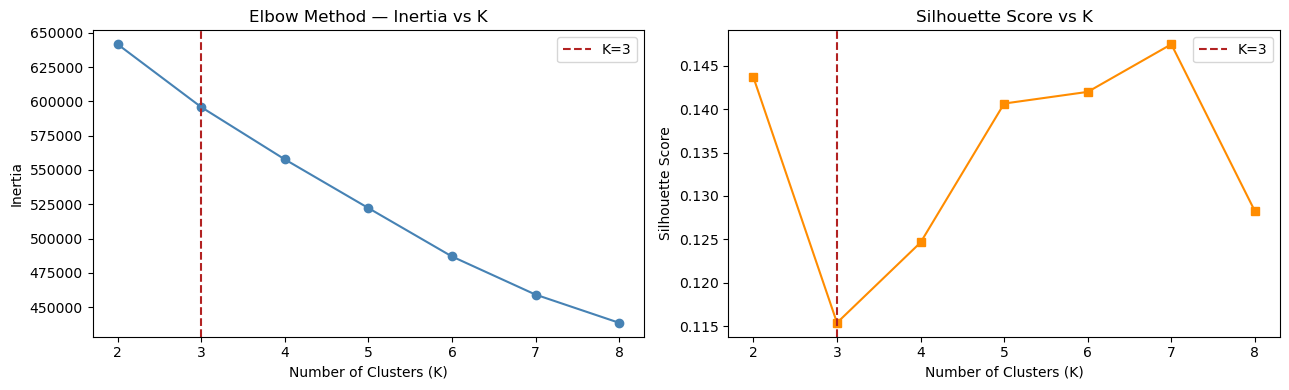

K=2  |  Silhouette: 0.1437
K=3  |  Silhouette: 0.1154
K=4  |  Silhouette: 0.1246
K=5  |  Silhouette: 0.1407
K=6  |  Silhouette: 0.1420
K=7  |  Silhouette: 0.1475
K=8  |  Silhouette: 0.1282


In [21]:
inertias = []
silhouette_scores = []
k_range = range(2, 9)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_cluster)
    inertias.append(km.inertia_)
    silhouette_scores.append(silhouette_score(X_cluster, labels, sample_size=5000, random_state=42))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Elbow
axes[0].plot(list(k_range), inertias, marker='o', color='steelblue')
axes[0].axvline(x=3, color='firebrick', linestyle='--', label='K=3')
axes[0].set_title('Elbow Method — Inertia vs K')
axes[0].set_xlabel('Number of Clusters (K)')
axes[0].set_ylabel('Inertia')
axes[0].legend()

# Silhouette
axes[1].plot(list(k_range), silhouette_scores, marker='s', color='darkorange')
axes[1].axvline(x=3, color='firebrick', linestyle='--', label='K=3')
axes[1].set_title('Silhouette Score vs K')
axes[1].set_xlabel('Number of Clusters (K)')
axes[1].set_ylabel('Silhouette Score')
axes[1].legend()

plt.tight_layout()
plt.show()

for k, s in zip(k_range, silhouette_scores):
    print(f"K={k}  |  Silhouette: {s:.4f}")

### Fit KMeans (K=3) & Assign Risk Labels
Confirmed best K=3 by the diagnostics above, now we fit the final model and map each cluster to clinical risk label based on mean utilization intensity. 

In [22]:
# ── Fit with K=3
km_final = KMeans(n_clusters=3, random_state=42, n_init=10)
cluster_df['cluster'] = km_final.fit_predict(X_cluster)

# ── Map cluster IDs → risk labels using mean of key utilization features
# Higher utilization (hospitalizations, ER, procedures) = higher risk
risk_proxy_cols = ['number_inpatient', 'number_emergency', 'time_in_hospital', 'number_diagnoses']
cluster_summary = cluster_df.groupby('cluster')[risk_proxy_cols].mean()
cluster_summary['risk_score'] = cluster_summary.mean(axis=1)
cluster_summary = cluster_summary.sort_values('risk_score')

risk_order = cluster_summary.index.tolist()  # ascending: low → high
risk_map = {risk_order[0]: 'Low', risk_order[1]: 'Medium', risk_order[2]: 'High'}

cluster_df['risk'] = cluster_df['cluster'].map(risk_map)

print("Cluster → Risk Mapping:")
print(risk_map)
print("\nCluster sizes:")
print(cluster_df['risk'].value_counts())

Cluster → Risk Mapping:
{0: 'Low', 2: 'Medium', 1: 'High'}

Cluster sizes:
risk
Medium    25967
Low       18847
High      15776
Name: count, dtype: int64


### Evaluating Cluster
Using three validation metrics: Silhouette Score, and Davies-Bouldin Index.

In [23]:
labels_final = km_final.labels_

sil  = silhouette_score(X_cluster, labels_final, sample_size=5000, random_state=42)
db   = davies_bouldin_score(X_cluster, labels_final)

print("=" * 45)
print("      Clustering Evaluation Metrics (K=3)")
print("=" * 45)
print(f"  Silhouette Score      : {sil:.4f}  (higher better, max 1.0)")
print(f"  Davies-Bouldin Index  : {db:.4f}  (lower better, min 0.0)")
print("=" * 45)

      Clustering Evaluation Metrics (K=3)
  Silhouette Score      : 0.1154  (higher better, max 1.0)
  Davies-Bouldin Index  : 2.3999  (lower better, min 0.0)


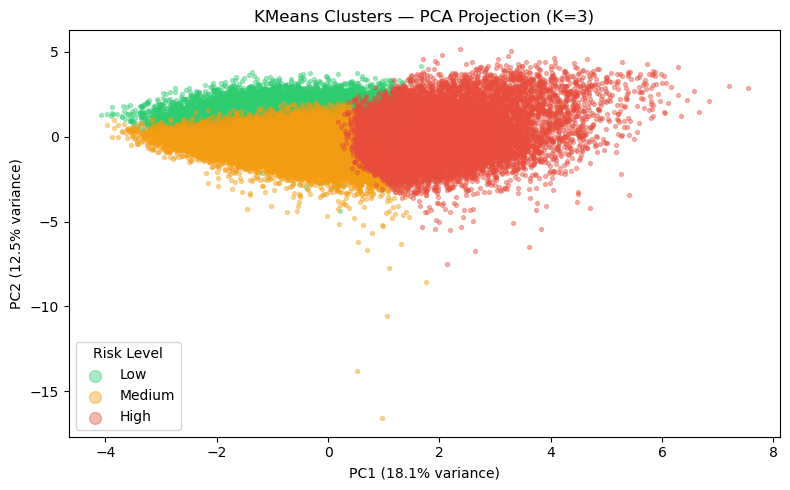

In [24]:
#PCA 2D Visualization of clusters
pca=PCA(n_components=2,random_state=42)
X_pca=pca.fit_transform(X_cluster)

pca_df=pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
pca_df['risk']=cluster_df['risk'].values

palette={'Low':'#2ecc71','Medium':'#f39c12','High':'#e74c3c'}

plt.figure(figsize=(8, 5))
for risk_level, color in palette.items():
    subset = pca_df[pca_df['risk'] == risk_level]
    plt.scatter(subset['PC1'], subset['PC2'], label=risk_level, alpha=0.4, s=8, color=color)

plt.title('KMeans Clusters — PCA Projection (K=3)')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
plt.legend(title='Risk Level', markerscale=3)
plt.tight_layout()
plt.show()


Cluster Risk Profile (Feature Means):


,time_in_hospital,num_lab_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses,age
risk,,,,,,,,
Low,3.19,33.28,14.16,0.23,0.05,0.13,6.56,58.93
Medium,3.07,42.88,12.13,0.25,0.14,0.17,7.31,59.67
High,7.63,56.61,23.53,0.37,0.11,0.29,8.46,66.05


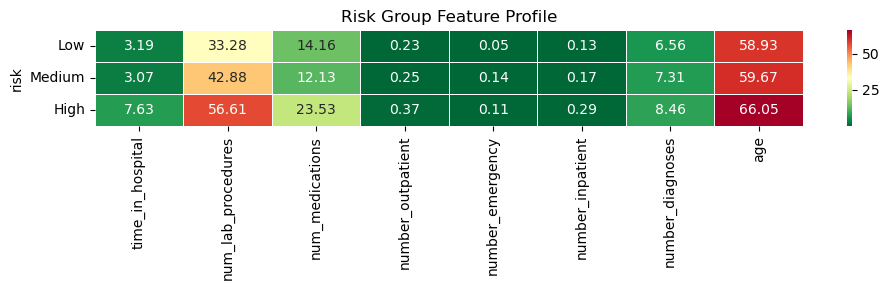

In [25]:
#Cluster profile: mean of key features by risk group
profile_cols=['time_in_hospital','num_lab_procedures','num_medications',
                'number_outpatient','number_emergency','number_inpatient','number_diagnoses','age']

profile=cluster_df.groupby('risk')[profile_cols].mean().round(2)
profile=profile.loc[['Low','Medium','High']]  # enforce order

print("\nCluster Risk Profile (Feature Means):")
display(profile)

#Heatmap
plt.figure(figsize=(10, 3))
sns.heatmap(profile, annot=True, fmt='.2f', cmap='RdYlGn_r', linewidths=0.5)
plt.title('Risk Group Feature Profile')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

### Attaching Risk Label to 'first_en'


In [26]:
#Align on index (cluster_df retains the original first_en index after dropna)
first_en=first_en.copy()
first_en.loc[cluster_df.index,'risk']=cluster_df['risk'].values

#Drop the rows that were excluded during clustering
first_en=first_en.dropna(subset=['risk'])

print(f"first_en shape with risk label: {first_en.shape}")
print(first_en['risk'].value_counts())

first_en shape with risk label: (60590, 46)
risk
Medium    25967
Low       18847
High      15776
Name: count, dtype: int64


## Part 2 - Readmission Prediction
### Strategy for Using Subsequent Encounters
**First encounters** (`first_en`) are used to train the model to avoid data leakage as the model sees only the initial presentation.

**Subsequent encounters** (`subsequent_en`) serves as the **held-out test set**. We propagate the `risk` label assigned at first to encounter to each patient's subsequent record, then test how well models trained on first encounters generalize to the real-world challenge of: *given patient presentation at index hospitalization, will the patient be readmitted?*


In [27]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, ConfusionMatrixDisplay,
    RocCurveDisplay, classification_report
)
from sklearn.pipeline import Pipeline
from sklearn.inspection import permutation_importance

### Prepare Features and Target

In [28]:
#Target - binarize readmitted
#'<30' = readmitted within 30 days (positive class = 1)
#'>30' or 'NO' = not readmitted within 30 days (negative class = 0)
def encode_readmitted(x):
    return 1 if str(x).strip() == '<30' else 0

first_en['readmitted_bin'] = first_en['readmitted'].apply(encode_readmitted)
print("Readmission class distribution (first_en):")
print(first_en['readmitted_bin'].value_counts())
print(f"Positive rate: {first_en['readmitted_bin'].mean():.3f}")

Readmission class distribution (first_en):
readmitted_bin
0    55250
1     5340
Name: count, dtype: int64
Positive rate: 0.088


In [29]:
#Define modeling features
#Drop ID columns, the raw readmitted label, and columns used only in clustering pipeline
drop_cols = ['encounter_id', 'patient_nbr', 'readmitted', 'readmitted_bin',
             'admission_source_id', 'admission_type_id', 'discharge_disposition_id']

feature_cols = [c for c in first_en.columns if c not in drop_cols]

print(f"Number of features: {len(feature_cols)}")
print(feature_cols)

Number of features: 40
['race', 'gender', 'age', 'time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'number_diagnoses', 'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'examide', 'citoglipton', 'insulin', 'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone', 'change', 'diabetesMed', 'ad_source_new', 'ad_type_new', 'dis_dispo_new', 'risk']


In [30]:
#Encode all categorical features (label encoding for tree models; same for LR/KNN after scaling)
model_df = first_en[feature_cols + ['readmitted_bin']].copy()

cat_cols = model_df.select_dtypes(include='object').columns.tolist()
print(f"Categorical columns to encode: {cat_cols}")

label_encoders = {}
for col in cat_cols:
    le_col = LabelEncoder()
    model_df[col] = le_col.fit_transform(model_df[col].astype(str))
    label_encoders[col] = le_col

model_df = model_df.dropna()
print(f"\nModeling dataset shape: {model_df.shape}")
model_df.head()

Categorical columns to encode: ['race', 'gender', 'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'examide', 'citoglipton', 'insulin', 'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone', 'change', 'diabetesMed', 'ad_source_new', 'ad_type_new', 'dis_dispo_new', 'risk']

Modeling dataset shape: (60590, 41)


,race,gender,age,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,...,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,ad_source_new,ad_type_new,dis_dispo_new,risk,readmitted_bin
4267,3,0,50,8,77,6,33,0,0,0,...,0,0,0,0,1,2,3,1,0,1
5827,3,0,50,2,49,1,11,0,0,0,...,0,0,0,1,0,2,0,1,1,0
67608,3,0,80,4,68,2,23,0,0,0,...,0,0,0,1,1,0,1,4,0,0
17494,3,0,80,3,46,0,20,0,0,0,...,0,0,0,0,1,0,1,1,2,0
2270,1,0,30,5,49,0,5,0,0,0,...,0,0,0,1,1,0,1,1,2,0


### Train & Test Split

In [31]:
X=model_df[feature_cols].values
y=model_df['readmitted_bin'].values

X_train, X_test, y_train, y_test=train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set  : {X_train.shape[0]} samples ({y_train.mean():.3f} positive rate)")
print(f"Test set      : {X_test.shape[0]} samples ({y_test.mean():.3f} positive rate)")

Training set  : 48472 samples (0.088 positive rate)
Test set      : 12118 samples (0.088 positive rate)


In [32]:
#Prepare subsequent encounters as external validation set
#Assign risk label from first encounter to each patient's subsequent records
risk_lookup=first_en.set_index('patient_nbr')['risk'].to_dict()

sub_df=subsequent_en.copy()
sub_df['risk']=sub_df['patient_nbr'].map(risk_lookup)
sub_df['readmitted_bin']=sub_df['readmitted'].apply(encode_readmitted)

#Keep patients whose first encounter risk was computed
sub_df=sub_df.dropna(subset=['risk'])

#Encode categoricals with the same label encoders
sub_model=sub_df[feature_cols + ['readmitted_bin']].copy()
for col in cat_cols:
    if col in sub_model.columns:
        le_col=label_encoders[col]
        # Handle unseen categories gracefully
        sub_model[col]=sub_model[col].astype(str).apply(
            lambda x: le_col.transform([x])[0] if x in le_col.classes_ else -1
        )

sub_model=sub_model.dropna()

X_sub=sub_model[feature_cols].values
y_sub=sub_model['readmitted_bin'].values

print(f"Subsequent encounters (external val): {X_sub.shape[0]} samples ({y_sub.mean():.3f} positive rate)")

Subsequent encounters (external val): 25137 samples (0.170 positive rate)


### Baseline Model: Logistic Regression

In [33]:
scaler_model=StandardScaler()
X_train_sc=scaler_model.fit_transform(X_train)
X_test_sc=scaler_model.transform(X_test)
X_sub_sc=scaler_model.transform(X_sub)

lr=LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
lr.fit(X_train_sc, y_train)

print("Logistic Regression trained.")

Logistic Regression trained.


### Model 2: Random Forest

In [34]:
rf=RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)

print("Random Forest trained.")

Random Forest trained.


### Model 3: Gradient Boosting

In [35]:
gb=GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    random_state=42
)
gb.fit(X_train, y_train)

print("Gradient Boosting trained.")

Gradient Boosting trained.


### Model 4: K-Nearest Neighbors

In [36]:
knn=KNeighborsClassifier(n_neighbors=15, weights='distance', n_jobs=-1)
knn.fit(X_train_sc, y_train)  # KNN also uses scaled data

print("KNN trained.")

KNN trained.


### Evaluation

In [37]:
def evaluate_model(name, model, X_te, y_te, X_ext, y_ext, scaled=False, scaler_obj=None):
        
    results = {}
    
    for label, Xv, yv in [('Internal Test', X_te, y_te), ('External (Subsequent)', X_ext, y_ext)]:
        
        if scaled and scaler_obj is not None:
            Xv=scaler_obj.transform(Xv)
        
        y_pred = model.predict(Xv)
        y_prob = model.predict_proba(Xv)[:, 1]
        
        results[label] = {
            'Accuracy' : accuracy_score(yv, y_pred),
            'Precision': precision_score(yv, y_pred, zero_division=0),
            'Recall'   : recall_score(yv, y_pred, zero_division=0),
            'F1'       : f1_score(yv, y_pred, zero_division=0),
            'ROC-AUC'  : roc_auc_score(yv, y_prob)
        }
    
    return results


models = [
    ('Logistic Regression (Baseline)', lr,  True,  scaler_model),
    ('Random Forest',                  rf,  False, None),
    ('Gradient Boosting',              gb,  False, None),
    ('KNN',                            knn, True,  scaler_model),
]

all_results = {}
for name, model, scaled, sc in models:
    all_results[name] = evaluate_model(
        name, model,
        X_test, y_test,
        X_sub, y_sub,
        scaled=scaled, scaler_obj=sc
    )

print("All models evaluated.")

All models evaluated.


In [38]:
#Summary Table
rows=[]
for model_name, result_dict in all_results.items():
    for split_name, metrics in result_dict.items():
        row={'Model': model_name, 'Split': split_name}
        row.update(metrics)
        rows.append(row)

summary_df=pd.DataFrame(rows).set_index(['Model', 'Split'])
summary_df=summary_df.round(4)

print("=" * 80)
print("                    MODEL EVALUATION SUMMARY")
print("=" * 80)
display(summary_df)

#Best model via ROC-AUC on internal test set
internal_auc={k: v['Internal Test']['ROC-AUC'] for k, v in all_results.items()}
best_model_name=max(internal_auc, key=internal_auc.get)
print(f"\n Best model by Internal ROC-AUC: {best_model_name} ({internal_auc[best_model_name]:.4f})")

                    MODEL EVALUATION SUMMARY


Accuracy  Precision  \
Model                          Split                                        
Logistic Regression (Baseline) Internal Test            0.6733     0.1376   
                               External (Subsequent)    0.3464     0.1871   
Random Forest                  Internal Test            0.7325     0.1499   
                               External (Subsequent)    0.4883     0.1926   
Gradient Boosting              Internal Test            0.9113     0.2941   
                               External (Subsequent)    0.8252     0.4024   
KNN                            Internal Test            0.9119     0.5000   
                               External (Subsequent)    0.8298     0.5081   

                                                      Recall      F1  ROC-AUC  
Model                          Split                                           
Logistic Regression (Baseline) Internal Test          0.5140  0.2171   0.6340  
                               External (Subsequent)  0.8480  0.3066   0.5963  
Random Forest                  Internal Test          0.4354  0.2230   0.6432  
                               External (Subsequent)  0.6276  0.2948   0.5675  
Gradient Boosting              Internal Test          0.0047  0.0092   0.6459  
                               External (Subsequent)  0.0539  0.0951   0.6072  
KNN                            Internal Test          0.0047  0.0093   0.5753  
                               External (Subsequent)  0.0292  0.0552   0.5714


✔ Best model by Internal ROC-AUC: Gradient Boosting (0.6459)


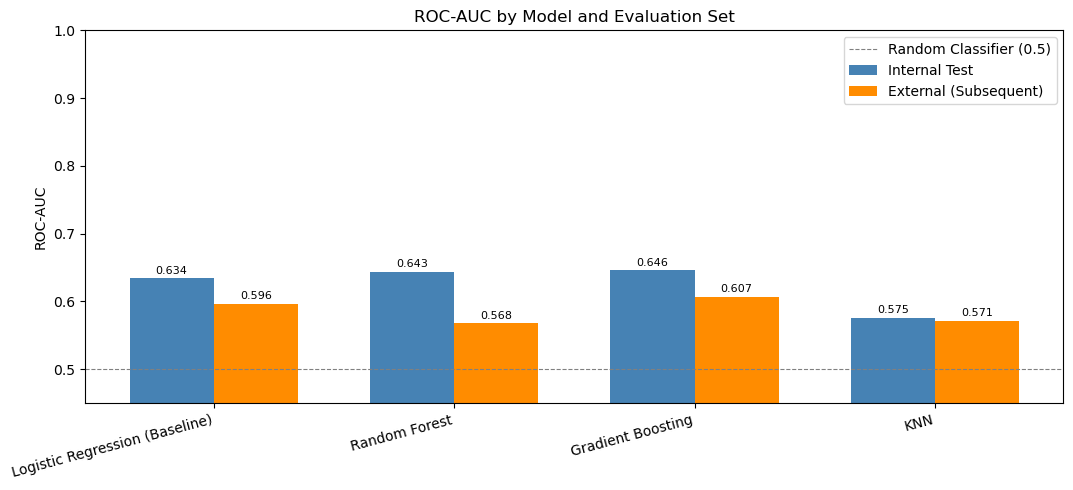

In [39]:
# Grouped bar chart for evaluation ROC-AUC comparison
internal_scores={k: v['Internal Test']['ROC-AUC'] for k, v in all_results.items()}
external_scores={k: v['External (Subsequent)']['ROC-AUC'] for k, v in all_results.items()}

model_names=list(internal_scores.keys())
x=np.arange(len(model_names))
width=0.35

fig, ax=plt.subplots(figsize=(11, 5))
bars1=ax.bar(x - width/2, [internal_scores[m] for m in model_names], width, label='Internal Test',         color='steelblue')
bars2=ax.bar(x + width/2, [external_scores[m] for m in model_names], width, label='External (Subsequent)', color='darkorange')

ax.axhline(0.5, color='grey', linestyle='--', linewidth=0.8, label='Random Classifier (0.5)')
ax.set_ylabel('ROC-AUC')
ax.set_title('ROC-AUC by Model and Evaluation Set')
ax.set_xticks(x)
ax.set_xticklabels(model_names, rotation=15, ha='right')
ax.set_ylim(0.45, 1.0)
ax.legend()
ax.bar_label(bars1, fmt='%.3f', padding=2, fontsize=8)
ax.bar_label(bars2, fmt='%.3f', padding=2, fontsize=8)

plt.tight_layout()
plt.show()

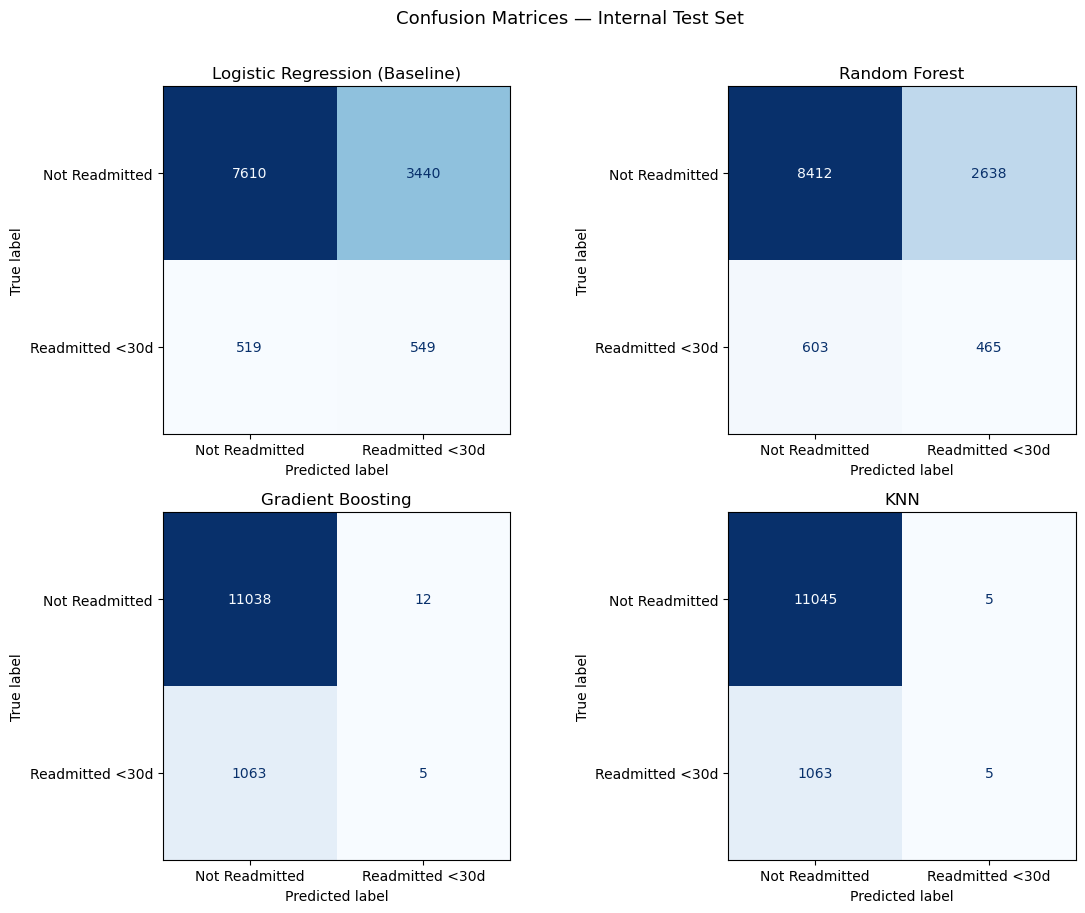

In [40]:
#Confusion Matrices (Internal Test Set)
fig, axes=plt.subplots(2, 2, figsize=(12, 9))
axes=axes.flatten()

for i, (name, model, scaled, sc) in enumerate(models):
    Xv=X_test_sc if scaled else X_test
    y_pred=model.predict(Xv)
    cm=confusion_matrix(y_test, y_pred)
    disp=ConfusionMatrixDisplay(cm, display_labels=['Not Readmitted', 'Readmitted <30d'])
    disp.plot(ax=axes[i], colorbar=False, cmap='Blues')
    axes[i].set_title(name)

plt.suptitle('Confusion Matrices — Internal Test Set', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

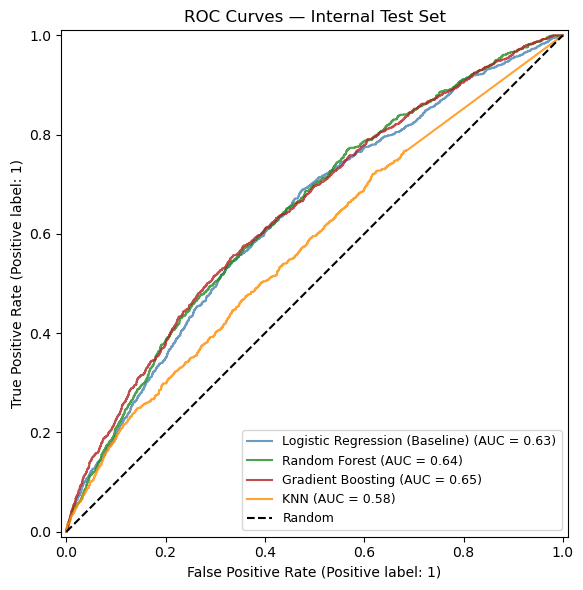

In [41]:
#ROC Curves
fig, ax=plt.subplots(figsize=(8, 6))
colors=['steelblue', 'forestgreen', 'firebrick', 'darkorange']

for (name, model, scaled, sc), color in zip(models, colors):
    Xv=X_test_sc if scaled else X_test
    RocCurveDisplay.from_estimator(model, Xv, y_test, ax=ax, name=name, color=color, alpha=0.8)

ax.plot([0,1],[0,1],'k--', label='Random')
ax.set_title('ROC Curves — Internal Test Set')
ax.legend(loc='lower right', fontsize=9)
plt.tight_layout()
plt.show()

### Feature Importance

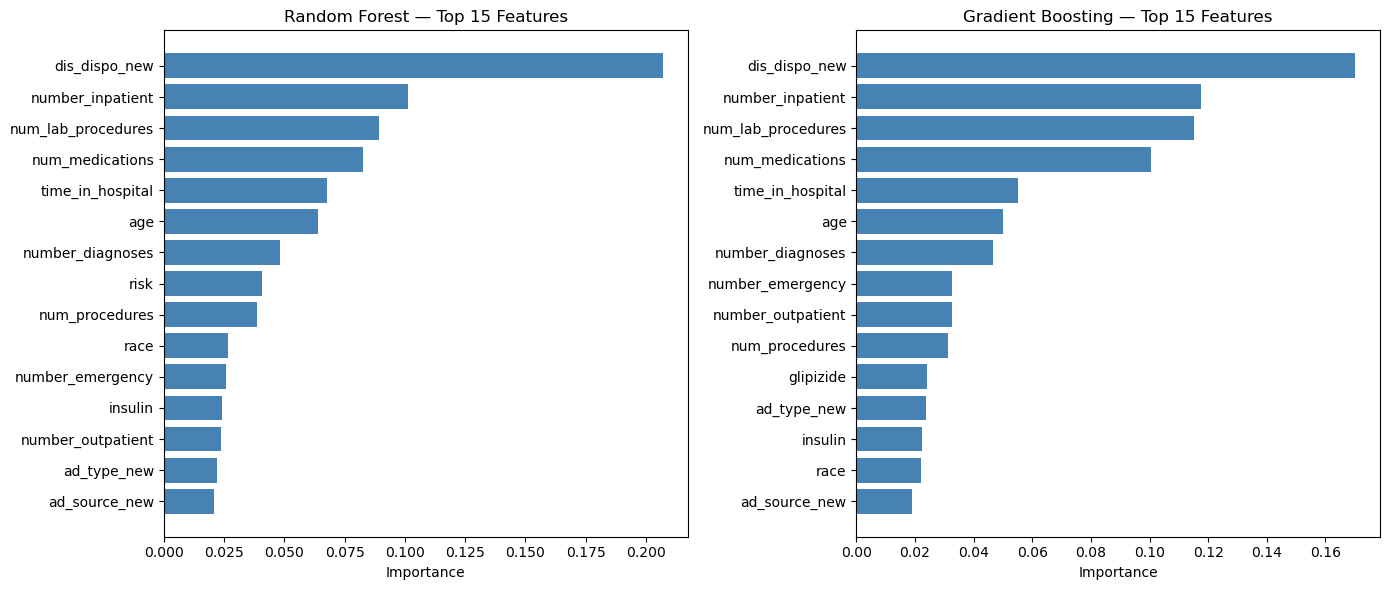

In [42]:
#Random Forest & Gradient Boosting: built-in feature importances
fig, axes=plt.subplots(1, 2, figsize=(14, 6))

for ax, (name, model) in zip(axes, [('Random Forest', rf), ('Gradient Boosting', gb)]):
    importances=model.feature_importances_
    indices=np.argsort(importances)[-15:]  # top 15
    ax.barh([feature_cols[i] for i in indices], importances[indices], color='steelblue')
    ax.set_title(f'{name} — Top 15 Features')
    ax.set_xlabel('Importance')

plt.tight_layout()
plt.show()

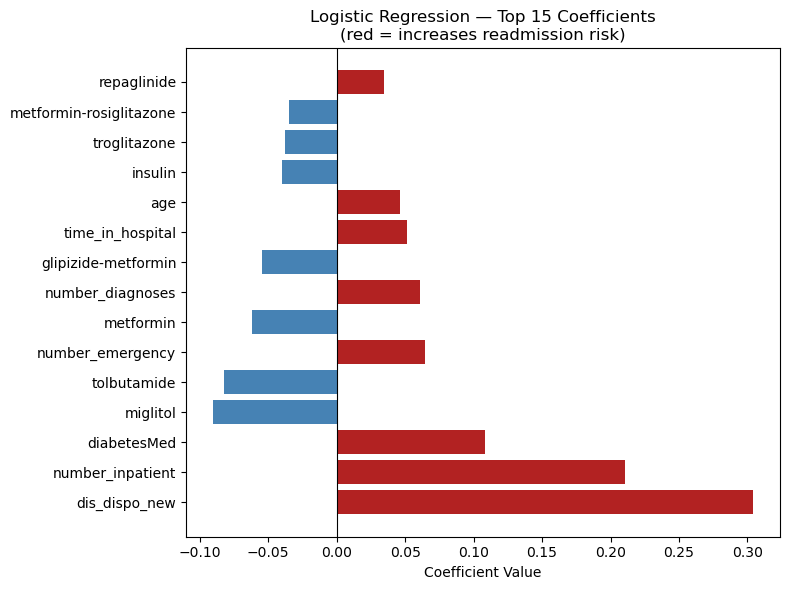

In [43]:
#Logistic Regression: top coefficients
coef_df=pd.DataFrame({
    'Feature'    : feature_cols,
    'Coefficient': lr.coef_[0]
}).sort_values('Coefficient', key=abs, ascending=False).head(15)

colors_lr=['firebrick' if c > 0 else 'steelblue' for c in coef_df['Coefficient']]

plt.figure(figsize=(8, 6))
plt.barh(coef_df['Feature'], coef_df['Coefficient'], color=colors_lr)
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Logistic Regression — Top 15 Coefficients\n(red = increases readmission risk)')
plt.xlabel('Coefficient Value')
plt.tight_layout()
plt.show()

### Cross Validation Stability Check

In [44]:
cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("5-Fold CV ROC-AUC (training set):")
print("-" * 50)

cv_results={}
for name, model, scaled, sc in models:
    Xtr=X_train_sc if scaled else X_train
    scores=cross_val_score(model, Xtr, y_train, cv=cv, scoring='roc_auc', n_jobs=-1)
    cv_results[name]=scores
    print(f"{name:<38}  mean={scores.mean():.4f}  std={scores.std():.4f}  folds={np.round(scores,4)}")

print("-" * 50)

5-Fold CV ROC-AUC (training set):
--------------------------------------------------
Logistic Regression (Baseline)          mean=0.6354  std=0.0073  folds=[0.6386 0.6245 0.6436 0.6293 0.6409]
Random Forest                           mean=0.6371  std=0.0082  folds=[0.6364 0.6281 0.6405 0.6297 0.6508]
Gradient Boosting                       mean=0.6426  std=0.0079  folds=[0.6486 0.6348 0.6535 0.6329 0.6434]
KNN                                     mean=0.5659  std=0.0052  folds=[0.5561 0.5695 0.5691 0.5649 0.57  ]
--------------------------------------------------


### Conclusion
Gradient Boosting was the best performing model. It achieved the highest internal test ROC-AUC of 0.6459 and the strongest cross-validation ROC-AUC of 0.6426. 